# Baseline Validation

Two complementary tests:
1. **Binary test**: NOVEL vs SKG (Mann-Whitney U, one-sided)
2. **3-way test**: NOVEL vs BLOG vs SKG (Kruskal-Wallis + post-hoc pairwise with Bonferroni correction)

**Expected ordering if system works:** NOVEL > BLOG > SKG
- NOVEL = peer-reviewed research papers introducing new methods/findings
- BLOG  = blog posts discussing research (informative but not primary research)
- SKG   = survey/knowledge-graph papers (consolidating existing work)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

FEATURE_MATRIX = '../../outputs/final/novelty_feature_matrix_with_score.csv'
PAPER_NODES    = '../../outputs/final/paper_nodes.csv'
OUT_DIR        = '../../outputs/final/'
VIS_DIR        = '../../outputs/visuals/'

print('Imports OK')

Imports OK


In [4]:
fm = pd.read_csv(FEATURE_MATRIX)
pn = pd.read_csv(PAPER_NODES)[['node_id', 'split', 'domain']]
pn = pn.rename(columns={'node_id': 'paper_id'})

df_all = fm.merge(pn, on='paper_id', how='left')

# Binary: NOVEL vs SKG only
df_binary = df_all[df_all['split'].isin(['NOVEL', 'SKG'])].copy()

# 3-way: all three splits
df_3way = df_all[df_all['split'].isin(['NOVEL', 'SKG', 'BLOG'])].copy()

print(f'Binary (NOVEL vs SKG) : {len(df_binary):,} papers')
print(df_binary['split'].value_counts().to_string())
print()
print(f'3-way (NOVEL/BLOG/SKG): {len(df_3way):,} papers')
print(df_3way['split'].value_counts().to_string())

Binary (NOVEL vs SKG) : 3,678 papers
split
SKG      2916
NOVEL     762

3-way (NOVEL/BLOG/SKG): 4,242 papers
split
SKG      2916
NOVEL     762
BLOG      564


In [7]:
# Composite Novelty — Summary Statistics
summary = df_3way.groupby('split')['composite_novelty'].agg(['mean','median','std','count'])
summary.columns = ['Mean', 'Median', 'Std', 'Count']
summary = summary.loc[['NOVEL', 'BLOG', 'SKG']]  # explicit order
print(summary.round(4))
print()
print(f"Gap NOVEL - SKG  : {summary.loc['NOVEL','Mean'] - summary.loc['SKG','Mean']:+.4f}")
print(f"Gap NOVEL - BLOG : {summary.loc['NOVEL','Mean'] - summary.loc['BLOG','Mean']:+.4f}")
print(f"Gap BLOG  - SKG  : {summary.loc['BLOG','Mean']  - summary.loc['SKG','Mean']:+.4f}")
print()
expected_order = (
    summary.loc['NOVEL','Mean'] >= summary.loc['BLOG','Mean'] >= summary.loc['SKG','Mean']
)
print(f"Expected ordering NOVEL >= BLOG >= SKG: {expected_order}")

         Mean  Median     Std  Count
split                               
NOVEL  0.7255  0.7592  0.1052    762
BLOG   0.6573  0.6460  0.1078    564
SKG    0.7594  0.7808  0.0835   2916

Gap NOVEL - SKG  : -0.0338
Gap NOVEL - BLOG : +0.0682
Gap BLOG  - SKG  : -0.1021

Expected ordering NOVEL >= BLOG >= SKG: False


In [8]:
# Binary: Mann-Whitney U (one-sided)
novel_scores = df_binary[df_binary['split'] == 'NOVEL']['composite_novelty'].dropna()
skg_scores   = df_binary[df_binary['split'] == 'SKG']['composite_novelty'].dropna()

u_stat, p_binary = stats.mannwhitneyu(novel_scores, skg_scores, alternative='greater')
n1, n2 = len(novel_scores), len(skg_scores)
r_binary = 1 - (2 * u_stat) / (n1 * n2)

print('BINARY TEST: NOVEL vs SKG (Mann-Whitney U, one-sided)')
print(f'H0: NOVEL composite <= SKG composite')
print(f'H1: NOVEL composite >  SKG composite')
print(f'U-statistic  : {u_stat:.2f}')
print(f'p-value      : {p_binary:.6f}')
print(f'Effect size r: {r_binary:.4f}')
print(f'Result       : {"PASS" if p_binary < 0.05 else "FAIL"}')

BINARY TEST: NOVEL vs SKG (Mann-Whitney U, one-sided)
H0: NOVEL composite <= SKG composite
H1: NOVEL composite >  SKG composite
U-statistic  : 902864.50
p-value      : 1.000000
Effect size r: 0.1873
Result       : FAIL


In [9]:
# 3-way: Kruskal-Wallis - Test whether the distributions of multiple groups are different.
blog_scores = df_3way[df_3way['split'] == 'BLOG']['composite_novelty'].dropna()

kw_stat, p_kw = stats.kruskal(novel_scores, blog_scores, skg_scores)

print('3-WAY TEST: Kruskal-Wallis')
print(f'H0: All three groups have same distribution')
print(f'H1: At least one group differs')
print(f'KW statistic : {kw_stat:.4f}')
print(f'p-value      : {p_kw:.6f}')
print(f'Result       : {"PASS — at least one group differs" if p_kw < 0.05 else "FAIL — no significant difference"}')
print()

# Post-hoc: pairwise Mann-Whitney with Bonferroni correction
groups = {'NOVEL': novel_scores, 'BLOG': blog_scores, 'SKG': skg_scores}
pairs = list(combinations(groups.keys(), 2))
n_comparisons = len(pairs)  # 3
alpha_corrected = 0.05 / n_comparisons  # Bonferroni

print(f'POST-HOC: Pairwise Mann-Whitney (Bonferroni alpha = {alpha_corrected:.4f})')
posthoc_results = []
for g1, g2 in pairs:
    u, p_raw = stats.mannwhitneyu(groups[g1], groups[g2], alternative='two-sided')
    p_adj = min(p_raw * n_comparisons, 1.0)  # Bonferroni adjusted
    n_a, n_b = len(groups[g1]), len(groups[g2])
    r = 1 - (2 * u) / (n_a * n_b)
    sig = p_adj < 0.05
    direction = f'{g1} > {g2}' if groups[g1].mean() > groups[g2].mean() else f'{g2} > {g1}'
    print(f'  {g1:6s} vs {g2:6s} | p_adj={p_adj:.4f} | r={r:+.4f} | sig={sig} | {direction}')
    posthoc_results.append({'pair': f'{g1} vs {g2}', 'p_raw': round(p_raw,6),
                             'p_adj_bonferroni': round(p_adj,6), 'effect_r': round(r,4),
                             'significant': sig, 'direction': direction})

── 3-WAY TEST: Kruskal-Wallis ──
H0: All three groups have same distribution
H1: At least one group differs
KW statistic : 439.9998
p-value      : 0.000000
Result       : PASS — at least one group differs

POST-HOC: Pairwise Mann-Whitney (Bonferroni alpha = 0.0167)
  NOVEL  vs BLOG   | p_adj=0.0000 | r=-0.3693 | sig=True | NOVEL > BLOG
  NOVEL  vs SKG    | p_adj=0.0000 | r=+0.1873 | sig=True | SKG > NOVEL
  BLOG   vs SKG    | p_adj=0.0000 | r=+0.5435 | sig=True | SKG > BLOG


* So SKG > NOVEL > BLOG

C:\Users\hp\AppData\Local\Temp\ipykernel_2236\1107830867.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_binary, x='split', y='composite_novelty',
C:\Users\hp\AppData\Local\Temp\ipykernel_2236\1107830867.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_3way, x='split', y='composite_novelty',


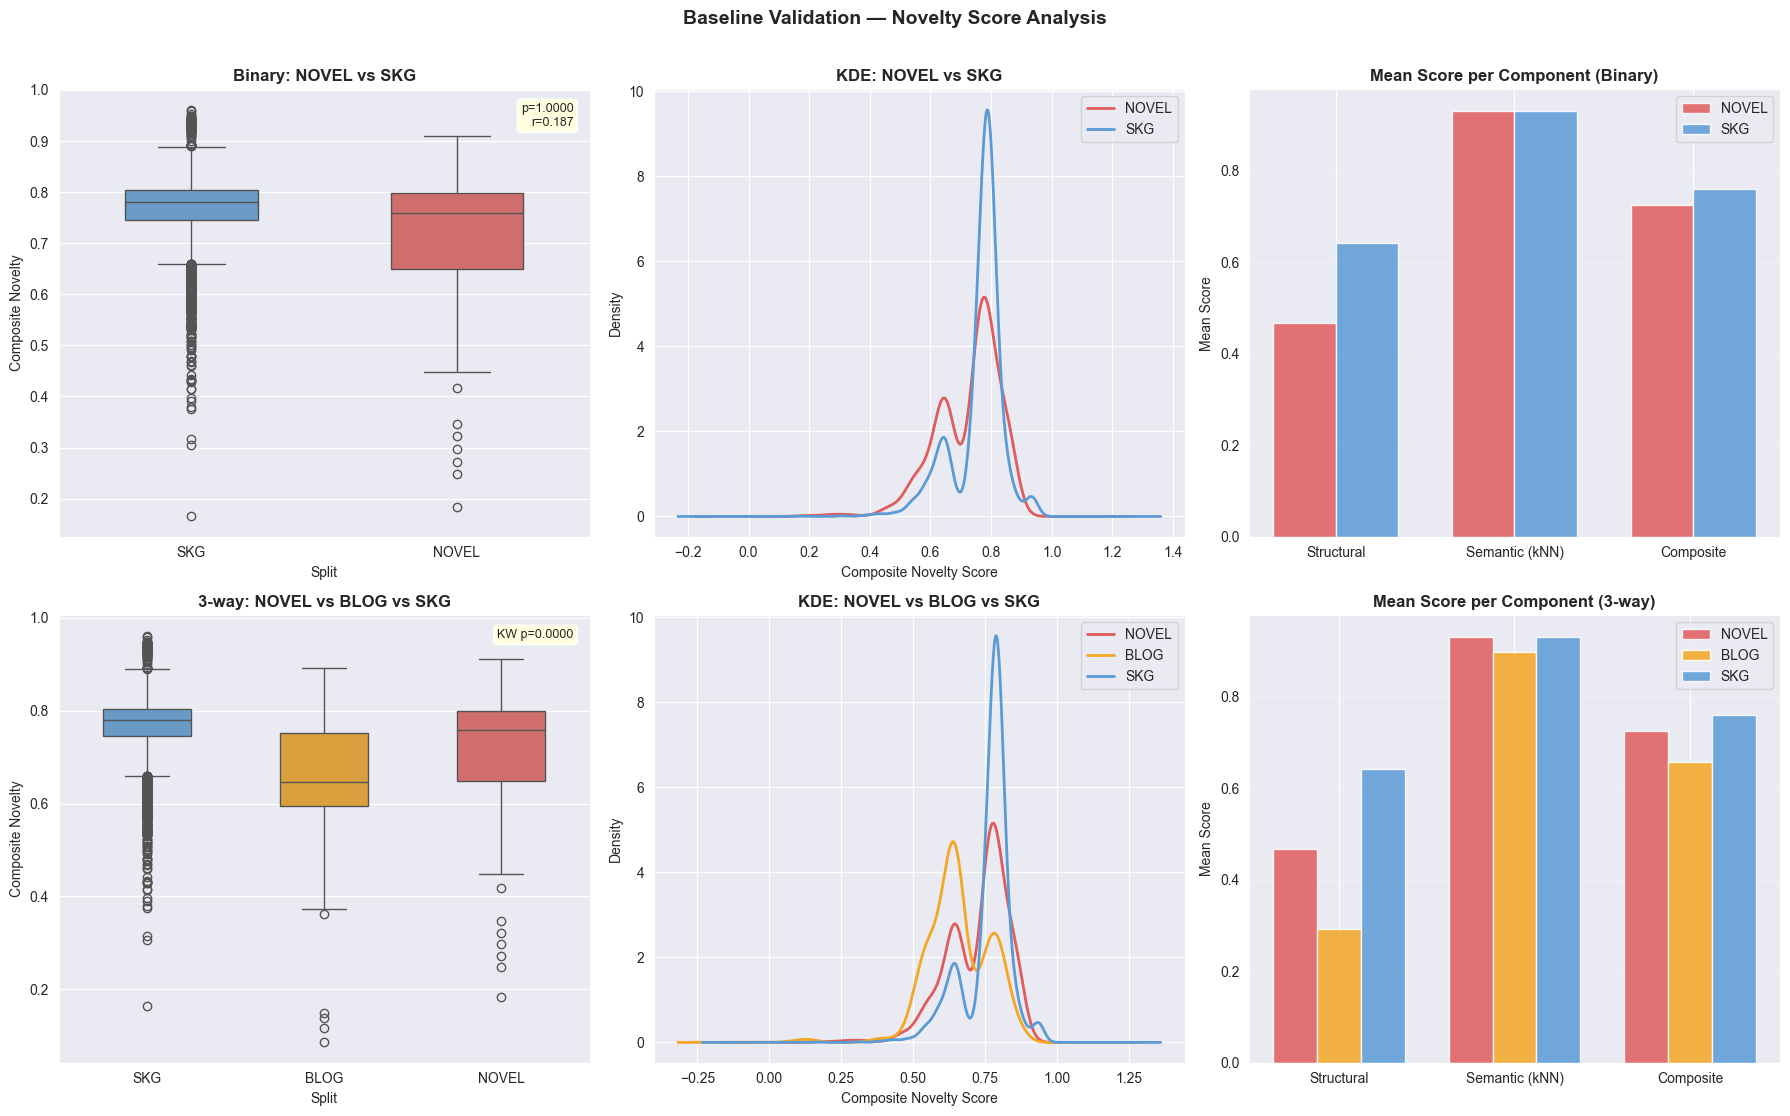

In [10]:
palette = {'NOVEL': '#E05C5C', 'BLOG': '#F5A623', 'SKG': '#5B9BD5'}
order3  = ['SKG', 'BLOG', 'NOVEL']
order2  = ['SKG', 'NOVEL']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Baseline Validation — Novelty Score Analysis', fontsize=14, fontweight='bold', y=1.01)

# ROW 1: Binary (NOVEL vs SKG)
# Boxplot
sns.boxplot(data=df_binary, x='split', y='composite_novelty',
            order=order2, palette=palette, ax=axes[0,0], width=0.5)
axes[0,0].set_title('Binary: NOVEL vs SKG', fontweight='bold')
axes[0,0].set_xlabel('Split'); axes[0,0].set_ylabel('Composite Novelty')
axes[0,0].annotate(f'p={p_binary:.4f}\nr={r_binary:.3f}',
    xy=(0.97,0.97), xycoords='axes fraction', ha='right', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

# KDE binary
for split in ['NOVEL','SKG']:
    df_binary[df_binary['split']==split]['composite_novelty'].dropna().plot.kde(
        ax=axes[0,1], label=split, color=palette[split], linewidth=2)
axes[0,1].set_title('KDE: NOVEL vs SKG', fontweight='bold')
axes[0,1].set_xlabel('Composite Novelty Score'); axes[0,1].legend()

# Per-component binary
components  = ['structural_novelty', 'semantic_knn', 'composite_novelty']
comp_labels = ['Structural', 'Semantic (kNN)', 'Composite']
means2 = df_binary.groupby('split')[components].mean()
x = np.arange(len(comp_labels)); w = 0.35
axes[0,2].bar(x-w/2, means2.loc['NOVEL'], w, label='NOVEL', color='#E05C5C', alpha=0.85)
axes[0,2].bar(x+w/2, means2.loc['SKG'],   w, label='SKG',   color='#5B9BD5', alpha=0.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(comp_labels)
axes[0,2].set_title('Mean Score per Component (Binary)', fontweight='bold')
axes[0,2].set_ylabel('Mean Score'); axes[0,2].legend(); axes[0,2].grid(axis='y', alpha=0.3)

# ROW 2: 3-way (NOVEL vs BLOG vs SKG)
# Boxplot
sns.boxplot(data=df_3way, x='split', y='composite_novelty',
            order=order3, palette=palette, ax=axes[1,0], width=0.5)
axes[1,0].set_title('3-way: NOVEL vs BLOG vs SKG', fontweight='bold')
axes[1,0].set_xlabel('Split'); axes[1,0].set_ylabel('Composite Novelty')
axes[1,0].annotate(f'KW p={p_kw:.4f}', xy=(0.97,0.97), xycoords='axes fraction',
    ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow'))

# KDE 3-way
for split in ['NOVEL','BLOG','SKG']:
    df_3way[df_3way['split']==split]['composite_novelty'].dropna().plot.kde(
        ax=axes[1,1], label=split, color=palette[split], linewidth=2)
axes[1,1].set_title('KDE: NOVEL vs BLOG vs SKG', fontweight='bold')
axes[1,1].set_xlabel('Composite Novelty Score'); axes[1,1].legend()

# Per-component 3-way
means3 = df_3way.groupby('split')[components].mean()
x = np.arange(len(comp_labels)); w = 0.25
axes[1,2].bar(x-w, means3.loc['NOVEL'], w, label='NOVEL', color='#E05C5C', alpha=0.85)
axes[1,2].bar(x,   means3.loc['BLOG'],  w, label='BLOG',  color='#F5A623', alpha=0.85)
axes[1,2].bar(x+w, means3.loc['SKG'],   w, label='SKG',   color='#5B9BD5', alpha=0.85)
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(comp_labels)
axes[1,2].set_title('Mean Score per Component (3-way)', fontweight='bold')
axes[1,2].set_ylabel('Mean Score'); axes[1,2].legend(); axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(VIS_DIR + 'baseline_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline_validation.png')

In [11]:
# Binary results (backward compatible)
binary_results = pd.DataFrame([{
    'novel_mean'  : round(novel_scores.mean(), 4),
    'skg_mean'    : round(skg_scores.mean(), 4),
    'mean_gap'    : round(novel_scores.mean() - skg_scores.mean(), 4),
    'u_stat'      : round(u_stat, 2),
    'p_value'     : round(p_binary, 6),
    'effect_size' : round(r_binary, 4),
    'significant' : p_binary < 0.05
}])
# binary_results.to_csv(OUT_DIR + 'baseline_validation_results.csv', index=False)
print('Saved: baseline_validation_results.csv')
print(binary_results.to_string(index=False))
print()

# 3-way results
threeway_results = pd.DataFrame(posthoc_results)
threeway_results['kw_stat']  = round(kw_stat, 4)
threeway_results['kw_pvalue'] = round(p_kw, 6)
threeway_results.to_csv(OUT_DIR + 'baseline_3way_results.csv', index=False)
print('Saved: baseline_3way_results.csv')
print(threeway_results[['pair','p_adj_bonferroni','effect_r','significant','direction']].to_string(index=False))
print()

# Ordering check
means = df_3way.groupby('split')['composite_novelty'].mean()
print('ORDERING CHECK')
print(f"NOVEL mean : {means.get('NOVEL', float('nan')):.4f}")
print(f"BLOG  mean : {means.get('BLOG',  float('nan')):.4f}")
print(f"SKG   mean : {means.get('SKG',   float('nan')):.4f}")
novel_m = means.get('NOVEL', 0)
blog_m  = means.get('BLOG',  0)
skg_m   = means.get('SKG',   0)
print(f"Expected order (NOVEL > BLOG > SKG): {novel_m >= blog_m >= skg_m}")

Saved: baseline_validation_results.csv
 novel_mean  skg_mean  mean_gap   u_stat  p_value  effect_size  significant
     0.7255    0.7594   -0.0338 902864.5      1.0       0.1873        False

         pair  p_adj_bonferroni  effect_r  significant    direction
NOVEL vs BLOG               0.0   -0.3693         True NOVEL > BLOG
 NOVEL vs SKG               0.0    0.1873         True  SKG > NOVEL
  BLOG vs SKG               0.0    0.5435         True   SKG > BLOG

ORDERING CHECK
NOVEL mean : 0.7255
BLOG  mean : 0.6573
SKG   mean : 0.7594
Expected order (NOVEL > BLOG > SKG): False
